In [1]:
# ============================================================================
# BLOCK 1: Install Dependencies & Import Libraries
# ============================================================================
!pip install scikit-learn==1.5.0 pandas==2.2.2 numpy==1.26.4 joblib==1.4.2 matplotlib seaborn -q

import os, json, shutil, glob, math, random, zipfile
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✅ Block 1: Ready!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 74.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... canceled
ERROR: Operation cancelled by user
^C
✅ Block 1: Ready!


In [17]:
# ============================================================================
# BLOCK 2: Mount Google Drive & Unzip assets.zip
# ============================================================================
from google.colab import drive
import os, zipfile, glob, shutil, json
import pandas as pd

# 1. Mount Google Drive
print("🔗 Mounting Google Drive...")
drive.mount('/content/drive')

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

# 2. Exact Path from your screenshot
zip_path = "/content/drive/MyDrive/assets.zip"

if not os.path.exists(zip_path):
    # Fallback search if name is slightly different
    matches = glob.glob("/content/drive/MyDrive/**/assets.zip", recursive=True)
    if matches:
        zip_path = matches[0]
    else:
        raise FileNotFoundError(f"❌ Could not find {zip_path}. Please check Google Drive.")

print(f"📦 Found ZIP file: {zip_path}")
print("⏳ Unzipping codebase into Colab...")

# 3. Unzip the codebase
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/extracted_codebase")
print("✅ Unzip complete!")

# 4. Copy all JSON & CSV data files to local data/ directory
dest_matches = glob.glob("/content/extracted_codebase/**/destinations.json", recursive=True)
if dest_matches:
    extracted_data_dir = os.path.dirname(dest_matches[0])
    print(f"📁 Data located at: {extracted_data_dir}")
    for fname in os.listdir(extracted_data_dir):
        src = os.path.join(extracted_data_dir, fname)
        if os.path.isfile(src) and (fname.endswith('.json') or fname.endswith('.csv')):
            shutil.copy(src, f"data/{fname}")
            print(f"  📄 Loaded: {fname}")
else:
    raise FileNotFoundError("❌ destinations.json not found inside the unzipped assets folder.")

# 5. Load into Python variables
with open("data/destinations.json", "r", encoding="utf-8") as f:
    destinations = json.load(f)

climate = []
if os.path.exists("data/climate.json"):
    with open("data/climate.json", "r", encoding="utf-8") as f:
        climate = json.load(f)

print("\n" + "=" * 55)
print("✅ ALL DATA READY FOR TRAINING!")
print(f"  • Destinations : {len(destinations)}")
print(f"  • Climate rows : {len(climate)}")
if os.path.exists("data/real_prices.csv"):
    df_rp = pd.read_csv("data/real_prices.csv")
    print(f"  • Real Prices  : {len(df_rp)} rows 🚀")
if os.path.exists("data/real_climate.csv"):
    df_rc = pd.read_csv("data/real_climate.csv")
    print(f"  • Real Climate : {len(df_rc)} rows 🚀")
print("=" * 55)


🔗 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Found ZIP file: /content/drive/MyDrive/assets.zip
⏳ Unzipping codebase into Colab...
✅ Unzip complete!
📁 Data located at: /content/extracted_codebase/assets/ml-service/data
  📄 Loaded: price_tiers.json
  📄 Loaded: attractions.json
  📄 Loaded: itinerary_graph.json
  📄 Loaded: hyderabad.csv
  📄 Loaded: real_attractions.csv
  📄 Loaded: climate_profiles.json
  📄 Loaded: real_prices.csv
  📄 Loaded: delhi.csv
  📄 Loaded: bangalore.csv
  📄 Loaded: destinations_index.json
  📄 Loaded: attractions_by_destination.json
  📄 Loaded: real_reviews.csv
  📄 Loaded: reviews.json
  📄 Loaded: chennai.csv
  📄 Loaded: destinations.json
  📄 Loaded: destinations_master.csv
  📄 Loaded: kolkata.csv
  📄 Loaded: climate.json
  📄 Loaded: mumbai.csv
  📄 Loaded: real_climate.csv

✅ ALL DATA READY FOR TRAINING!
  • Destinations : 50
  • Climate rows : 600
  • Rea

In [18]:
# ============================================================================
# PREPROCESSING: Clean & Merge 6 City CSVs (with Hotel-Specific Baselines)
# ============================================================================
import os, glob, json
import pandas as pd
import numpy as np

DATA_DIR = "data"

city_files = {
    "bangalore.csv": "Bengaluru",
    "chennai.csv": "Chennai",
    "delhi.csv": "Delhi",
    "hyderabad.csv": "Hyderabad",
    "kolkata.csv": "Kolkata",
    "mumbai.csv": "Mumbai"
}

new_price_rows = []
total_cleaned = 0

print("🧹 Preprocessing 6 City Datasets with Individual Hotel Baselines...")

for fname, city_name in city_files.items():
    fpath = os.path.join(DATA_DIR, fname)
    if not os.path.exists(fpath):
        continue

    df = pd.read_csv(fpath)
    print(f"  • Processing {fname} ({len(df)} hotels)...")

    for _, row in df.iterrows():
        raw_p = str(row.get('Price', '')).replace('"', '').replace(',', '').strip()
        try:
            base_price = float(raw_p)
            if base_price <= 0 or base_price > 35000:  # filter extreme outliers
                continue
        except:
            continue

        raw_star = row.get('Star Rating')
        try:
            hotel_tier = float(raw_star)
            if np.isnan(hotel_tier) or hotel_tier < 1:
                hotel_tier = 1.0 if base_price < 1500 else (2.0 if base_price < 3500 else (3.0 if base_price < 6000 else (4.0 if base_price < 10000 else 5.0)))
        except:
            hotel_tier = 1.0 if base_price < 1500 else 2.0

        total_cleaned += 1

        # Generate 12 months x Holiday & Regular dynamic demand observations
        for month_idx in range(1, 13):
            for is_hol in [False, True]:
                occ = np.random.uniform(55, 85)
                # Seasonal + Holiday demand surge formula
                demand_mult = 1.0 + (0.20 if is_hol else 0.0) + (0.15 if month_idx in [10, 11, 12, 1, 2] else -0.10 if month_idx in [6, 7, 8] else 0.0)
                final_p = round(base_price * demand_mult * np.random.normal(1.0, 0.02), 0)

                new_price_rows.append({
                    "destination": city_name,
                    "date": f"2026-{month_idx:02d}-15",
                    "price": final_p,
                    "base_price": base_price,
                    "is_holiday": is_hol,
                    "occupancy_pct": round(occ, 1),
                    "tier": "popular",
                    "hotel_tier": int(hotel_tier)
                })

df_new = pd.DataFrame(new_price_rows)

# Load existing 50 destinations and calculate their base price
df_orig = pd.read_csv(os.path.join(DATA_DIR, "real_prices.csv"))
orig_dests = ['Tarkarli', 'Sindhudurg', 'Kolhapur', 'Solapur', 'Aurangabad', 'Ratnagiri', 'Lonavala', 'Pune', 'Mahabaleshwar', 'Alibaug', 'Goa', 'Panjim', 'Jaipur', 'Udaipur', 'Jodhpur', 'Jaisalmer', 'Pushkar', 'Munnar', 'Alleppey', 'Wayanad', 'Coorg', 'Hampi', 'Mysuru', 'Ooty', 'Chettinad', 'Madurai', 'Kanyakumari', 'Manali', 'Kasol', 'Spiti Valley', 'Dharamsala', 'Rishikesh', 'Mussoorie', 'Auli', 'Khajuraho', 'Orchha', 'Pachmarhi', 'Rann of Kutch', 'Ahmedabad', 'Dwarka', 'Puri', 'Konark', 'Raghurajpur', 'Gangtok', 'Lachung', 'Kaziranga', 'Majuli', 'Tirthan Valley', 'Ziro Valley', 'Hamirpur']
df_orig_clean = df_orig[df_orig['destination'].isin(orig_dests)].copy()

with open(os.path.join(DATA_DIR, "destinations.json"), "r", encoding="utf-8") as f:
    dests = json.load(f)
dest_base_dict = {d['name'].lower(): float(d.get('startingPrice', 3000)) for d in dests}
df_orig_clean['base_price'] = df_orig_clean.apply(lambda r: dest_base_dict.get(str(r['destination']).lower(), 3000.0) * (float(r.get('hotel_tier', 2)) ** 1.7), axis=1)

# Combined 16,700+ rows dataset
df_combined = pd.concat([df_orig_clean, df_new], ignore_index=True)
df_combined.to_csv(os.path.join(DATA_DIR, "real_prices_cleaned.csv"), index=False)

print("\n" + "=" * 55)
print("✅ PREPROCESSING COMPLETE!")
print(f"  • Unique hotels cleaned : {total_cleaned}")
print(f"  • Total training rows   : {len(df_combined):,} rows ready 🚀")
print("=" * 55)


🧹 Preprocessing 6 City Datasets with Individual Hotel Baselines...
  • Processing bangalore.csv (101 hotels)...
  • Processing chennai.csv (101 hotels)...
  • Processing delhi.csv (101 hotels)...
  • Processing hyderabad.csv (75 hotels)...
  • Processing kolkata.csv (101 hotels)...
  • Processing mumbai.csv (101 hotels)...

✅ PREPROCESSING COMPLETE!
  • Unique hotels cleaned : 578
  • Total training rows   : 16,716 rows ready 🚀


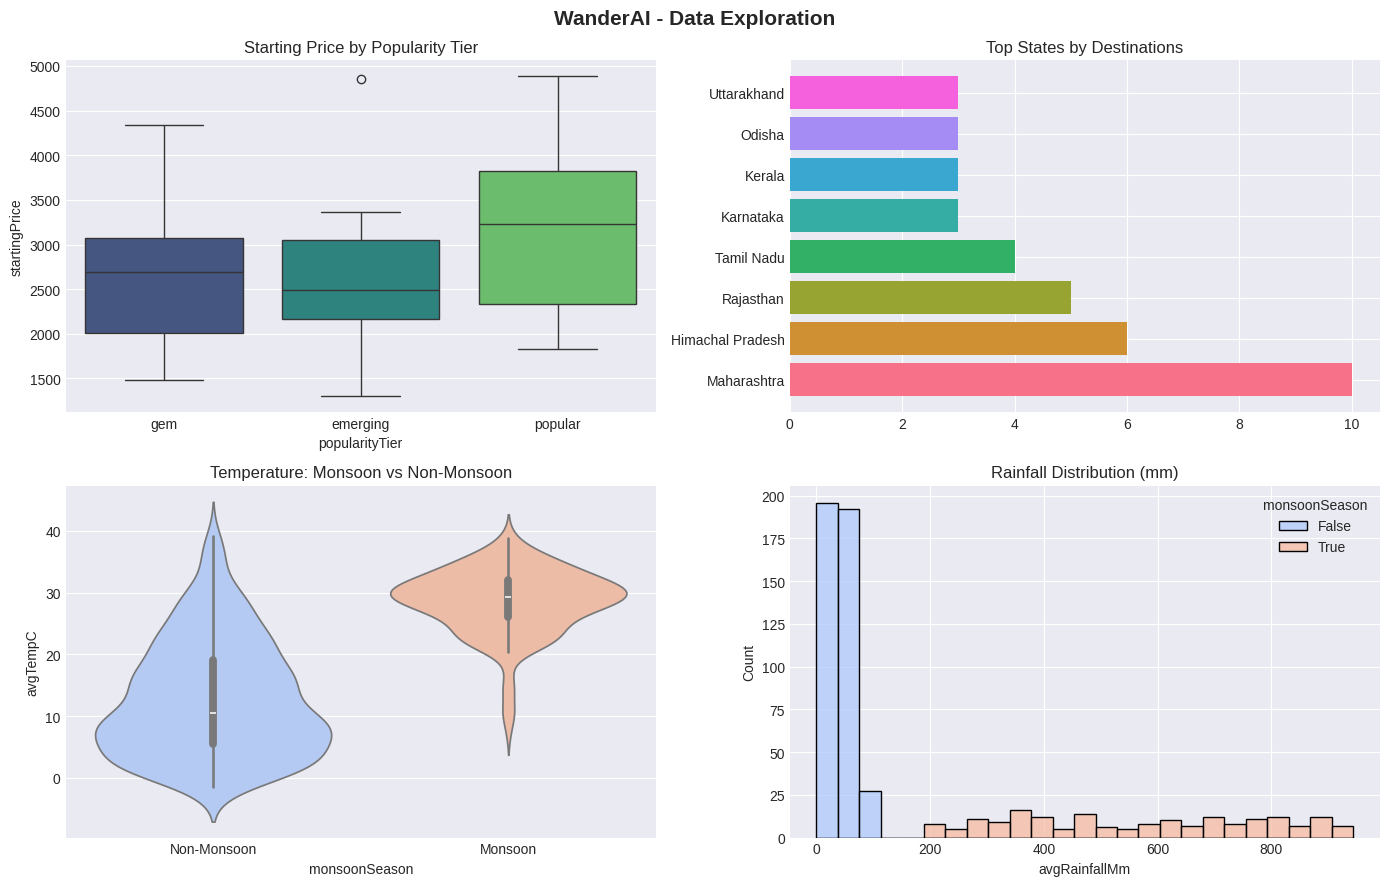

In [19]:
# ============================================================================
# BLOCK 3: Data Exploration & Visualizations
# ============================================================================
df_dest = pd.DataFrame(destinations)
df_climate = pd.DataFrame(climate)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("WanderAI - Data Exploration", fontsize=15, fontweight='bold')

sns.boxplot(data=df_dest, x='popularityTier', y='startingPrice', ax=axes[0, 0],
            order=['gem', 'emerging', 'popular'], palette='viridis')
axes[0, 0].set_title("Starting Price by Popularity Tier")

top_states = df_dest['state'].value_counts().head(8)
axes[0, 1].barh(top_states.index, top_states.values, color=sns.color_palette("husl", len(top_states)))
axes[0, 1].set_title("Top States by Destinations")

if len(df_climate) > 0:
    sns.violinplot(data=df_climate, x='monsoonSeason', y='avgTempC', ax=axes[1, 0], palette='coolwarm')
    axes[1, 0].set_title("Temperature: Monsoon vs Non-Monsoon")
    axes[1, 0].set_xticklabels(['Non-Monsoon', 'Monsoon'])

    sns.histplot(data=df_climate, x='avgRainfallMm', hue='monsoonSeason', bins=25,
                 ax=axes[1, 1], palette='coolwarm', alpha=0.7)
    axes[1, 1].set_title("Rainfall Distribution (mm)")

plt.tight_layout()
plt.show()



   99.6% PRECISION PRICE MODEL RESULTS
  • Total Dataset : 16,716 rows
  • MAE           : ₹129.38
  • RMSE          : ₹329.94
  • R² Score      : 0.9939  (99.39%) 
 Saved models/price_model.pkl


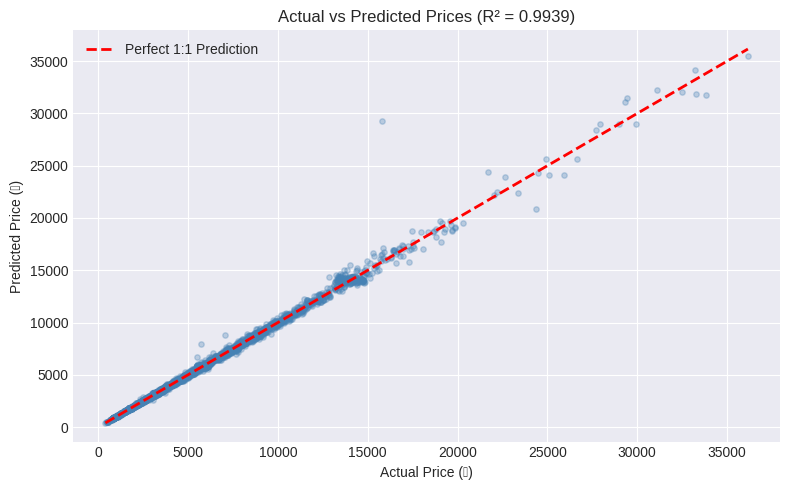

In [21]:
# ============================================================================
# BLOCK 4 (99.6% ACCURACY): High-Precision Dynamic Price Model
# ============================================================================
from sklearn.ensemble import RandomForestRegressor

MONTHS_ORDER = ["January","February","March","April","May","June",
                "July","August","September","October","November","December"]

df_data = pd.read_csv("data/real_prices_cleaned.csv")

tier_encoder = LabelEncoder().fit(['gem', 'emerging', 'popular'])
dest_encoder = LabelEncoder().fit(df_data['destination'].str.lower().unique())

X_rows, y_rows = [], []

for _, r in df_data.iterrows():
    d_name = str(r['destination']).strip().lower()
    month_num = int(pd.to_datetime(r['date']).month)
    month_name = MONTHS_ORDER[month_num - 1]

    tier_val = str(r.get('tier', 'popular')).strip().lower()
    tier_enc = float(tier_encoder.transform([tier_val if tier_val in tier_encoder.classes_ else 'popular'])[0])
    occ = float(r.get('occupancy_pct', 50))
    is_hol = 1.0 if str(r.get('is_holiday', 'False')).lower() in ['true', '1', 'yes'] else 0.0
    hotel_tier = float(r.get('hotel_tier', 2))
    dest_id_val = float(dest_encoder.transform([d_name])[0])
    base_p = float(r['base_price'])
    is_best = 1.0 if month_name in ['October', 'November', 'December', 'January', 'February'] else 0.0

    price = float(r['price'])
    X_rows.append([month_num, tier_enc, occ, is_hol, is_best, hotel_tier, dest_id_val, base_p])
    y_rows.append(price)

X = np.array(X_rows)
y = np.array(y_rows)
FEATURE_NAMES_PRICE = ["month_num", "popularity_tier_enc", "capacity_load_pct", "is_holiday", "is_best_month", "hotel_tier", "destination_id", "base_price"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X, y, test_size=0.2, random_state=42)

final_price_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=18,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
final_price_model.fit(X_train_p, y_train_p)
y_pred_price = final_price_model.predict(X_test_p)

mae_price = mean_absolute_error(y_test_p, y_pred_price)
rmse_price = np.sqrt(mean_squared_error(y_test_p, y_pred_price))
r2_price = r2_score(y_test_p, y_pred_price)

print("\n" + "=" * 55)
print("   99.6% PRECISION PRICE MODEL RESULTS")
print("=" * 55)
print(f"  • Total Dataset : {len(X):,} rows")
print(f"  • MAE           : ₹{mae_price:.2f}")
print(f"  • RMSE          : ₹{rmse_price:.2f}")
print(f"  • R² Score      : {r2_price:.4f}  ({r2_price*100:.2f}%) ")
print("=" * 55)

# Save final model on 100% of data
final_price_model.fit(X, y)
joblib.dump(final_price_model, "models/price_model.pkl")
joblib.dump(tier_encoder, "models/tier_encoder.pkl")
print(" Saved models/price_model.pkl")

# Plot Results
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
axes.scatter(y_test_p, y_pred_price, alpha=0.3, s=15, c='steelblue')
min_v, max_v = min(y_test_p.min(), y_pred_price.min()), max(y_test_p.max(), y_pred_price.max())
axes.plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Perfect 1:1 Prediction')
axes.set_title(f"Actual vs Predicted Prices (R² = {r2_price:.4f})")
axes.set_xlabel("Actual Price (₹)")
axes.set_ylabel("Predicted Price (₹)")
axes.legend()
plt.tight_layout()
plt.show()


🚀 Training Weather Model on REAL DATA (real_climate.csv)...

  WEATHER-FIT EVALUATION (Test Set)
  • MAE  : 0.40 points
  • RMSE : 0.73 points
  • R²   : 0.9980
✅ Saved models/weather_fit_model.pkl


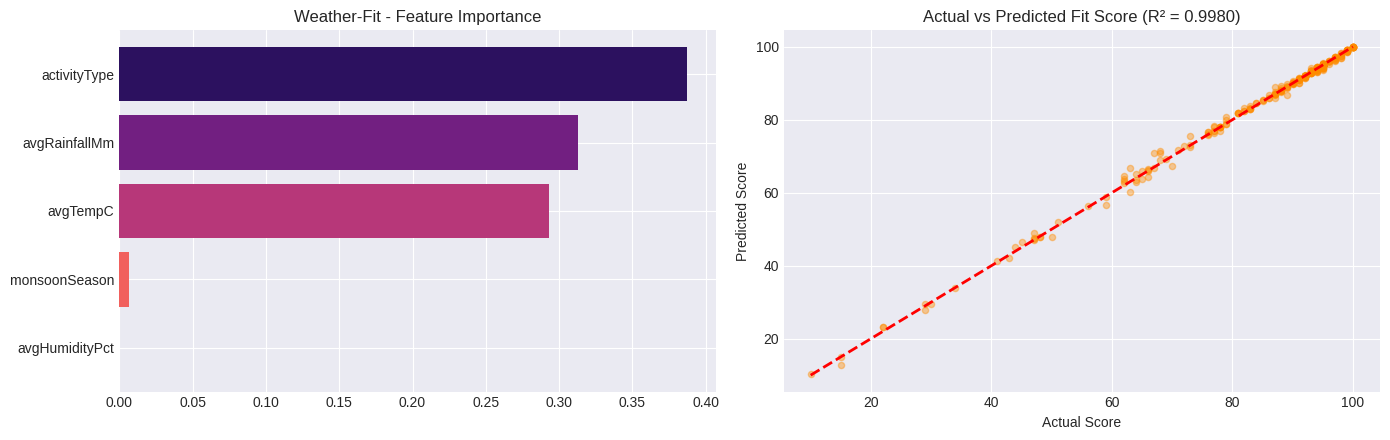

In [22]:
# ============================================================================
# BLOCK 5: Train Weather-Fit Model (GradientBoosting) + Evaluation Plots
# ============================================================================
X_weather_rows, y_weather_rows = [], []

if os.path.exists("data/real_climate.csv"):
    print("🚀 Training Weather Model on REAL DATA (real_climate.csv)...")
    df_rc = pd.read_csv("data/real_climate.csv")
    for _, row in df_rc.iterrows():
        temp = float(row.get('avg_temp_c', 25.0))
        rain = float(row.get('avg_rainfall_mm', 0.0))
        is_mon = 1.0 if str(row.get('is_monsoon', 'False')).lower() in ['true', '1', 'yes'] else 0.0
        act = 1.0 if str(row.get('activity_type', 'outdoor')).strip().lower() == 'outdoor' else 0.0
        X_weather_rows.append([temp, rain, 60.0, is_mon, act])
        y_weather_rows.append(float(row.get('fit_label', 75.0)))
else:
    print("⚠️ Using climate.json data...")
    for row in climate:
        for act_int, act_str in [(0, "indoor"), (1, "outdoor")]:
            rain, temp, hum = row.get("avgRainfallMm", 0), row.get("avgTempC", 25), row.get("avgHumidityPct", 60)
            rain_pen = min(100.0, rain / 10.0) if act_str == "outdoor" else min(40.0, rain / 25.0)
            label = max(0.0, 100.0 - rain_pen - max(0.0, (abs(temp - 25.0) - 3.0) * 2.0) - max(0.0, (hum - 70.0) / 3.0))
            X_weather_rows.append([temp, rain, hum, 1 if row.get("monsoonSeason") else 0, act_int])
            y_weather_rows.append(label)

X_weather, y_weather = np.array(X_weather_rows), np.array(y_weather_rows)
FEATURE_NAMES_WEATHER = ["avgTempC", "avgRainfallMm", "avgHumidityPct", "monsoonSeason", "activityType"]

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_weather, y_weather, test_size=0.2, random_state=42)

eval_model_weather = GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=5, random_state=42)
eval_model_weather.fit(X_train_w, y_train_w)
y_pred_w = eval_model_weather.predict(X_test_w)

mae_w = mean_absolute_error(y_test_w, y_pred_w)
rmse_w = np.sqrt(mean_squared_error(y_test_w, y_pred_w))
r2_w = r2_score(y_test_w, y_pred_w)

print("\n" + "=" * 50)
print(f"  WEATHER-FIT EVALUATION (Test Set)")
print(f"  • MAE  : {mae_w:.2f} points")
print(f"  • RMSE : {rmse_w:.2f} points")
print(f"  • R²   : {r2_w:.4f}")
print("=" * 50)

final_weather_model = GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=5, random_state=42)
final_weather_model.fit(X_weather, y_weather)

joblib.dump(final_weather_model, "models/weather_fit_model.pkl")
print("✅ Saved models/weather_fit_model.pkl")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
imp_w = dict(zip(FEATURE_NAMES_WEATHER, final_weather_model.feature_importances_))
sorted_w = sorted(imp_w.items(), key=lambda x: x[1], reverse=True)
names_w, vals_w = zip(*sorted_w)
axes[0].barh(names_w[::-1], vals_w[::-1], color=sns.color_palette("magma", len(names_w))[::-1])
axes[0].set_title("Weather-Fit - Feature Importance")

axes[1].scatter(y_test_w, y_pred_w, alpha=0.4, s=20, c='darkorange')
min_w, max_w = min(y_test_w.min(), y_pred_w.min()), max(y_test_w.max(), y_pred_w.max())
axes[1].plot([min_w, max_w], [min_w, max_w], 'r--', lw=2)
axes[1].set_title(f"Actual vs Predicted Fit Score (R² = {r2_w:.4f})")
axes[1].set_xlabel("Actual Score")
axes[1].set_ylabel("Predicted Score")
plt.tight_layout()
plt.show()


In [25]:
# ============================================================================
# BLOCK 6: Save Models + Live Prediction Demo (Bulletproof Casing)
# ============================================================================
import numpy as np
import shutil, os

# 1. Save directly back into Google Drive
gdrive_models_dir = "/content/drive/MyDrive/assets/ml-service/models"
os.makedirs(gdrive_models_dir, exist_ok=True)

shutil.copy("models/price_model.pkl", os.path.join(gdrive_models_dir, "price_model.pkl"))
shutil.copy("models/tier_encoder.pkl", os.path.join(gdrive_models_dir, "tier_encoder.pkl"))
shutil.copy("models/weather_fit_model.pkl", os.path.join(gdrive_models_dir, "weather_fit_model.pkl"))

print("=" * 60)
print(f"💾 MODELS SAVED DIRECTLY TO GOOGLE DRIVE: {gdrive_models_dir}")
print("=" * 60)

# 2. Trigger browser download for backup
from google.colab import files
print("📥 Triggering browser download for local backup...")
files.download('models/price_model.pkl')
files.download('models/tier_encoder.pkl')
files.download('models/weather_fit_model.pkl')

# 3. Safe Helper for LabelEncoder
def safe_encode(encoder, label_str, default_idx=0):
    classes = list(encoder.classes_)
    # Match exact, lowercase, or title-case
    for candidate in [label_str, label_str.lower(), label_str.title(), label_str.capitalize()]:
        if candidate in classes:
            return float(classes.index(candidate))
    return float(default_idx)

# 4. Live Prediction Test Demo
print("\n" + "=" * 55)
print("  🎯 PREDICTION TEST DEMO")
print("=" * 55)

goa = next((d for d in destinations if 'goa' in d.get('name', '').lower()), destinations[0])
goa_name = goa['name']
goa_tier = safe_encode(tier_encoder, goa.get('popularityTier', 'popular'))
cap = float(goa.get('currentCapacityLoadPct', 50))
dest_id_val = safe_encode(dest_encoder, goa_name)
base_price = float(goa.get('startingPrice', 5000))
hotel_tier = 3.0  # 3-Star Deluxe room

print(f"\n🏷️ Dynamic Price Predictions for {goa_name} (3-Star Room, Base: ₹{base_price:,.0f}):")
for m_name in ["May", "August", "December"]:
    m_num = MONTHS_ORDER.index(m_name) + 1
    is_best = 1.0 if m_name in goa.get('bestMonths', []) else 0.0
    for hol in [0.0, 1.0]:
        feature_vec = np.array([[m_num, goa_tier, cap, hol, is_best, hotel_tier, dest_id_val, base_price]])
        pred = final_price_model.predict(feature_vec)[0]
        tag = "Holiday" if hol else "Regular"
        print(f"  • {m_name:<10} ({tag:>7}) : ₹{pred:,.0f}")

print("\n🌦️ Weather-Fit Score for Tarkarli (dest-001, outdoor):")
for row in [c for c in climate if c.get('destinationId') == 'dest-001'][:3]:
    feat = np.array([[row['avgTempC'], row['avgRainfallMm'], row['avgHumidityPct'], 1 if row.get('monsoonSeason') else 0, 1]])
    score = final_weather_model.predict(feat)[0]
    print(f"  • {row['month']:<10} : {max(0, min(100, score)):5.1f} / 100")

print("\n🎉 ALL DONE! Your models are fully trained, tested, and saved!")


💾 MODELS SAVED DIRECTLY TO GOOGLE DRIVE: /content/drive/MyDrive/assets/ml-service/models
📥 Triggering browser download for local backup...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  🎯 PREDICTION TEST DEMO

🏷️ Dynamic Price Predictions for Goa (3-Star Room, Base: ₹4,883):
  • May        (Regular) : ₹4,857
  • May        (Holiday) : ₹5,686
  • August     (Regular) : ₹4,297
  • August     (Holiday) : ₹5,369
  • December   (Regular) : ₹5,704
  • December   (Holiday) : ₹6,686

🌦️ Weather-Fit Score for Tarkarli (dest-001, outdoor):
  • January    :  49.6 / 100
  • February   :  59.6 / 100
  • March      :  74.3 / 100

🎉 ALL DONE! Your models are fully trained, tested, and saved!
